# <p style="background-image: url(https://png.pngtree.com/thumb_back/fh260/background/20231027/pngtree-hexagonal-abstract-background-with-a-black-textured-surface-image_13704307.png);font-family:calibri;font-size:140%;color: #FFD700; text-align:center;border-radius:20px 20px 20px 20px; padding:20px; border:solid 7px #FFD700;"> **MRI IMAGES CLASSIFICATION USING YOLO** 

In [6]:
%pip install albumentations opencv-python pillow pathlib tqdm seaborn plotly matplotlib ultralytics --quiet

Note: you may need to restart the kernel to use updated packages.


In [7]:
import albumentations as A
import numpy as np
import cv2
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import yaml
import os
import random
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics.utils import metrics

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/evakhromeeva/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
%pip install ultralytics
import ultralytics
ultralytics.checks()
from ultralytics import YOLO

Ultralytics 8.4.33 🚀 Python-3.14.0 torch-2.11.0 CPU (Apple M1)
Setup complete ✅ (8 CPUs, 16.0 GB RAM, 300.3/460.4 GB disk)


In [22]:
%pip install --upgrade nbformat>=4.2.0 --quiet

zsh:1: 4.2.0 not found
Note: you may need to restart the kernel to use updated packages.


Ultralytics is a company known for its work in the field of computer vision and deep learning. They are particularly notable for developing YOLO (You Only Look Once) models, which are widely used for object detection tasks. Their YOLOv8 model, for example, is a recent and advanced version of the YOLO series, designed to be faster and more accurate in detecting objects in images and videos. Ultralytics provides tools and libraries that simplify the process of training and deploying these models, making them more accessible for a range of applications.

Label file ../dataset/task3_1-brain-mri/Val/No Tumor/labels/image(55).txt not found, skipping this image.
Label file ../dataset/task3_1-brain-mri/Val/No Tumor/labels/image(61).txt not found, skipping this image.
Label file ../dataset/task3_1-brain-mri/Val/Glioma/labels/gg (342).txt is empty, skipping this image.


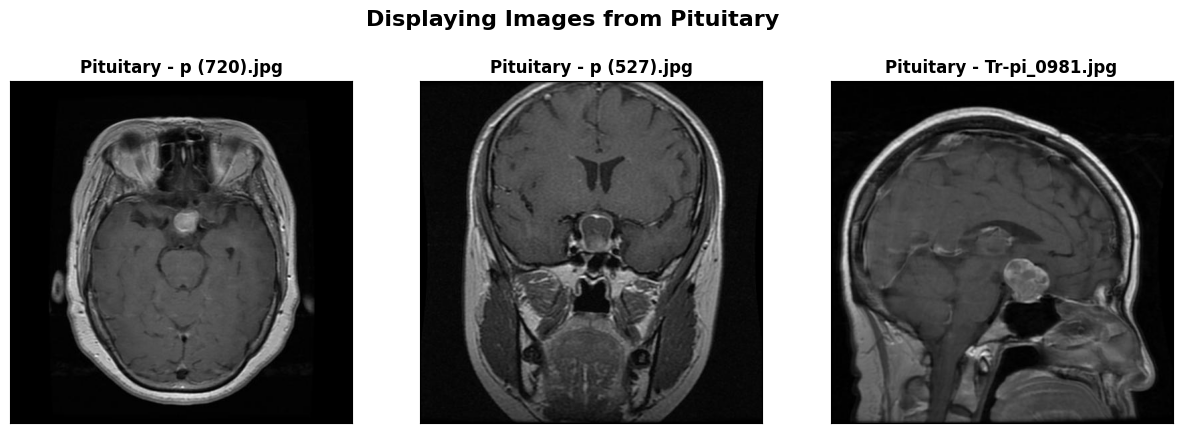

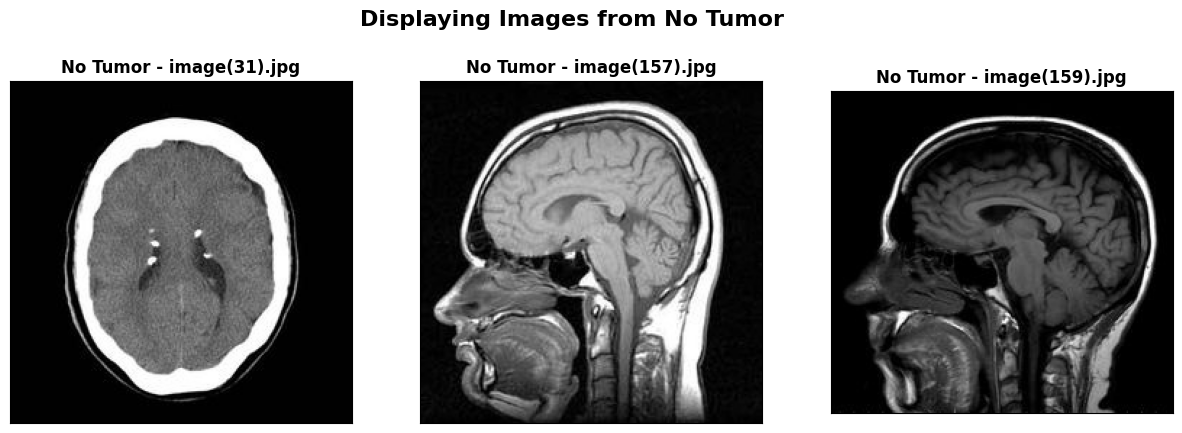

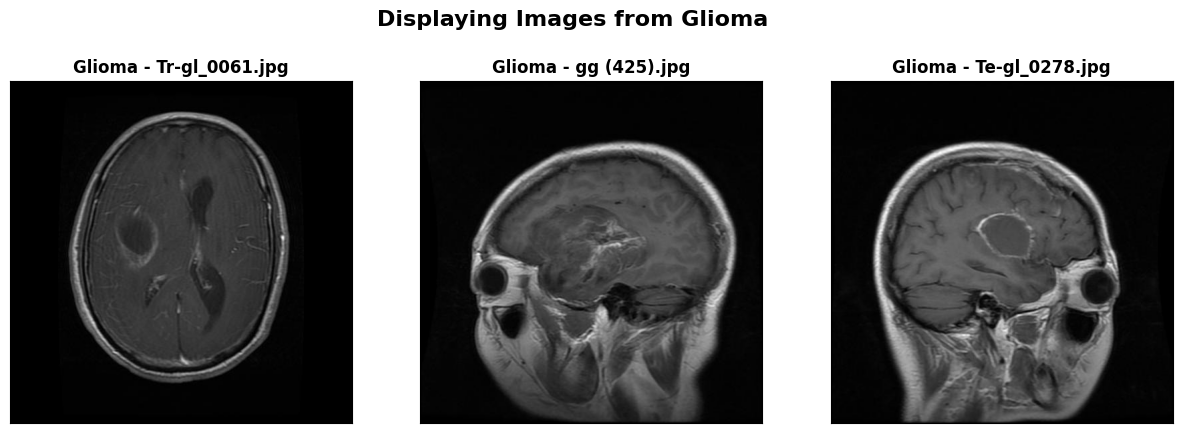

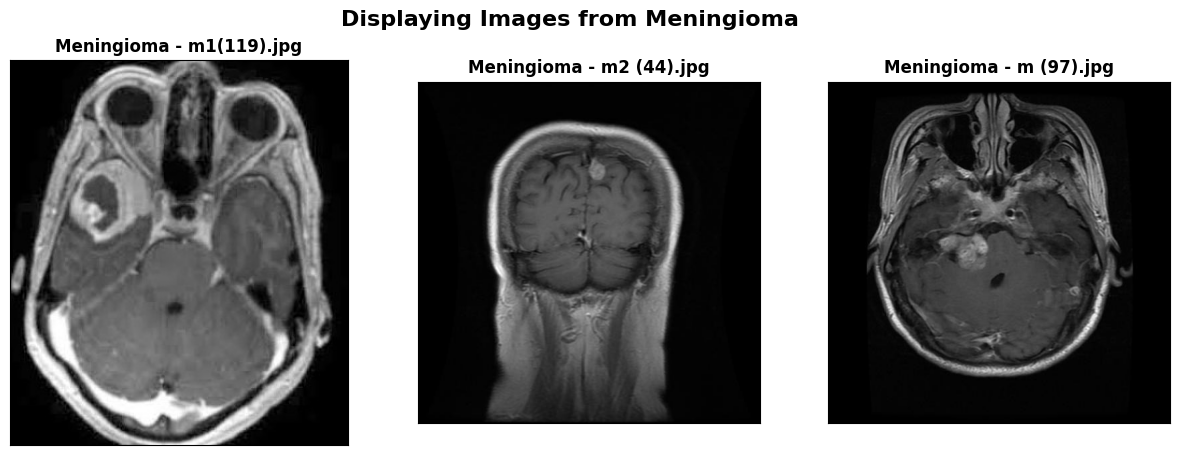

In [18]:
def load_data(directory):
    images =[]
    labels = []
    for class_name in os.listdir(directory):
        images_path = os.path.join(directory, class_name, 'images')
        labels_path = os.path.join(directory, class_name, 'labels')
        for image in os.listdir(images_path):
            img = cv2.imread(os.path.join(images_path, image))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            label_file = image.replace('.jpg', '.txt')
            label_file_path = os.path.join(labels_path, label_file)
            if os.path.exists(label_file_path):
                with open(label_file_path, 'r') as file:
                    label_data = file.readline().strip().split()
                    if len(label_data) > 0:
                        images.append(img)
                        labels.append(label_data)
                    else:
                        print(f"Label file {label_file_path} is empty, skipping this image.")
            else:
                print(f"Label file {label_file_path} not found, skipping this image.")
    return images, labels

# Paths to data directories
train_path = '../dataset/task3_1-brain-mri/Train'
val_path = '../dataset/task3_1-brain-mri/Val'

# Load training and validation data
train_images, train_labels = load_data(train_path)
val_images, val_labels = load_data(val_path)

def display_random_images(directory, num_images=3):
#     images, labels = load_data(train_path)
    
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        images_path = os.path.join(directory, class_name, 'images')
        images = os.listdir(images_path)
        selected_images = random.sample(images, num_images)
        
        fig, axes = plt.subplots(1,3, figsize=(15,5))
        fig.suptitle(f"Displaying Images from {class_name}", fontsize=16, fontweight='bold')
        
        for ax, image in zip(axes, selected_images):
            image_path = os.path.join(images_path, image)
            img = mpimg.imread(image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"{class_name} - {os.path.basename(image)}",fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])

display_random_images(train_path)

# <p style="background-image: url(https://png.pngtree.com/thumb_back/fh260/background/20231027/pngtree-hexagonal-abstract-background-with-a-black-textured-surface-image_13704307.png);font-family:calibri;font-size:140%;color: #FFD700; text-align:center;border-radius:20px 20px 20px 20px; padding:20px; border:solid 7px #FFD700;"> **IMAGES PREPROCESSING** 

OpenCV (cv2) offers a wide range of functions for image preprocessing. Here are some common operations and the corresponding functions:

# 1. **Reading and Displaying Images:**

* **cv2.imread(filename, flags):** Reads an image from a file. The **flags** parameter specifies the color type of the image. Common flags include **cv2.IMREAD_COLOR** (default, loads a color image), **cv2.IMREAD_GRAYSCALE** (loads a grayscale image), and **cv2.IMREAD_UNCHANGED** (loads the image as is, including alpha channel).
* **cv2.imshow(window_name, image)**: Displays an image in a window.
* **cv2.waitKey(delay)**: Waits for a key event. The delay parameter specifies the time in milliseconds. If 0, it waits indefinitely.
* **cv2.destroyAllWindows()**: Closes all OpenCV windows.

# 2. **Resizing Images:**

* **cv2.resize(image, dsize, fx, fy, interpolation):** Resizes an image to the specified dimensions. dsize is the new size, **fx** and **fy** are scaling factors. interpolation can be **cv2.INTER_LINEAR, cv2.INTER_CUBIC, or cv2.INTER_NEAREST,** among others.

# 3. **Cropping Images:**

You can crop an image using slicing. For example: **cropped_image = image[y:y+h, x:x+w]**, where **(x, y)** is the top-left corner and **(w, h)** is the width and height of the cropped area.

# 4. **Color Conversion:**

* **cv2.cvtColor(image, code):** Converts an image from one color space to another. For example, cv2.COLOR_BGR2GRAY converts an image from BGR to grayscale.


Thre are many functions related to image pre-processing with **cv2** but we will be using only resizing.

In [19]:
# Image Preprocessing
def images_preprocessing(images):
    processed_images = []
    for img in images:
        img_resized = cv2.resize(img, (640, 640))
        processed_images.append(img_resized)
    return np.array(processed_images)

train_images = images_preprocessing(train_images)
val_images   = images_preprocessing(val_images)


# <p style="background-image: url(https://png.pngtree.com/thumb_back/fh260/background/20231027/pngtree-hexagonal-abstract-background-with-a-black-textured-surface-image_13704307.png);font-family:calibri;font-size:140%;color: #FFD700; text-align:center;border-radius:20px 20px 20px 20px; padding:20px; border:solid 7px #FFD700;"> **IMAGES COUNT IN EACH CLASS** 

In [23]:
def count_images_in_folders(base_path):
    image_counts = []
    
    # Get all directories in the base_path
    main_directories = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    
    for main_dir in main_directories:
        images_dir_path = os.path.join(base_path, main_dir, 'images')
        
        images = [f for f in os.listdir(images_dir_path) if os.path.isfile(os.path.join(images_dir_path, f))]
        
        print(f'\033[1mNumber of Images in {main_dir} : {len(images)}\033[0m')
        image_counts.append({'Class': main_dir, 'Count': len(images)})
    
    df = pd.DataFrame(image_counts).sort_values(by='Count', ascending=False)
    
    # Вариант 1: Круговая диаграмма (Pie Chart) с matplotlib
    colors = ['#a6a832','#32a0a8', '#599173', '#bfbf95']
    explode = [0.1 if i == 0 else 0 for i in range(len(df))]  # Выделяем первый сектор
    
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(df['Count'], 
                                       labels=df['Class'], 
                                       colors=colors[:len(df)],
                                       explode=explode,
                                       autopct='%1.1f%%',
                                       textprops={'fontsize': 12, 'fontfamily': 'Times New Roman'},
                                       wedgeprops={'edgecolor': 'black', 'linewidth': 2})
    
    # Настройка внешнего вида текста
    for text in texts:
        text.set_fontfamily('Times New Roman')
        text.set_fontsize(12)
    for autotext in autotexts:
        autotext.set_fontfamily('Times New Roman')
        autotext.set_fontsize(10)
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title('Number of Images in Each Class', fontfamily='Times New Roman', 
                 fontsize=30, color='#191e1f', pad=20)
    ax.axis('equal')  # Ensure pie is circular
    
    # Настройка фона
    fig.patch.set_facecolor('#dff2ef')
    ax.set_facecolor('#dff2ef')
    
    plt.tight_layout()
    plt.show()
    
    # Вариант 2: Столбчатая диаграмма (Bar Plot) с seaborn (часто нагляднее для сравнения)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.barplot(data=df, x='Class', y='Count', palette=colors[:len(df)], ax=ax)
    
    # Добавляем значения на столбцы
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(i, row['Count'] + max(df['Count'])*0.01, 
                str(row['Count']), 
                ha='center', va='bottom', 
                fontfamily='Times New Roman', fontsize=12, fontweight='bold')
    
    ax.set_title('Number of Images in Each Class', fontfamily='Times New Roman', 
                 fontsize=30, color='#191e1f', pad=20)
    ax.set_xlabel('Class', fontfamily='Times New Roman', fontsize=15)
    ax.set_ylabel('Count', fontfamily='Times New Roman', fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    
    # Настройка фона
    fig.patch.set_facecolor('#dff2ef')
    ax.set_facecolor('#dff2ef')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return

Number of Images in Pituitary : 1424
Number of Images in No Tumor : 711
Number of Images in Glioma : 1153
Number of Images in Meningioma : 1449


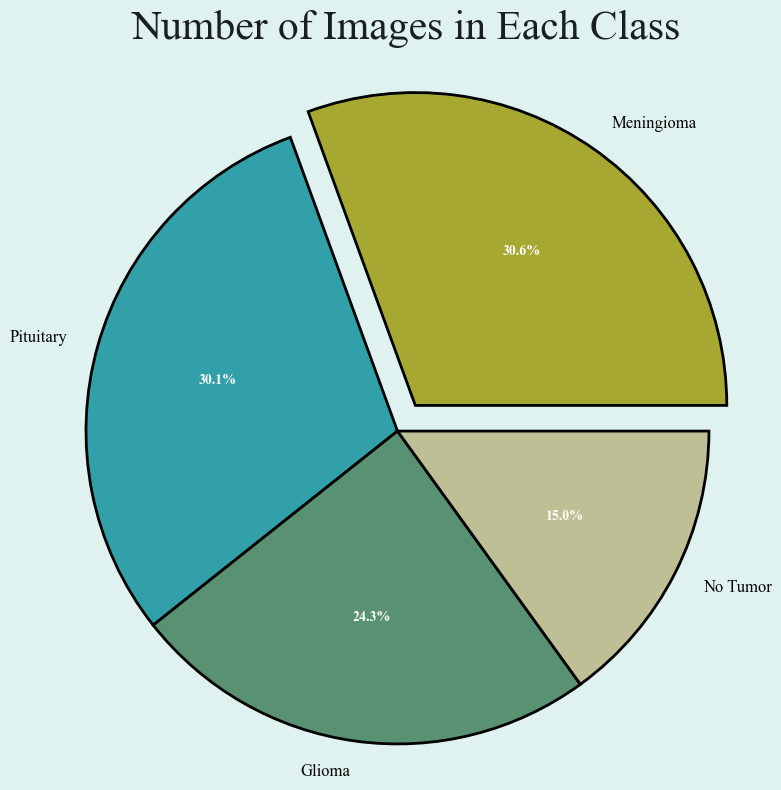

/var/folders/vb/ln0by8yd5g188n3xwgtwx5dr0000gn/T/ipykernel_39555/1618559537.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Class', y='Count', palette=colors[:len(df)], ax=ax)


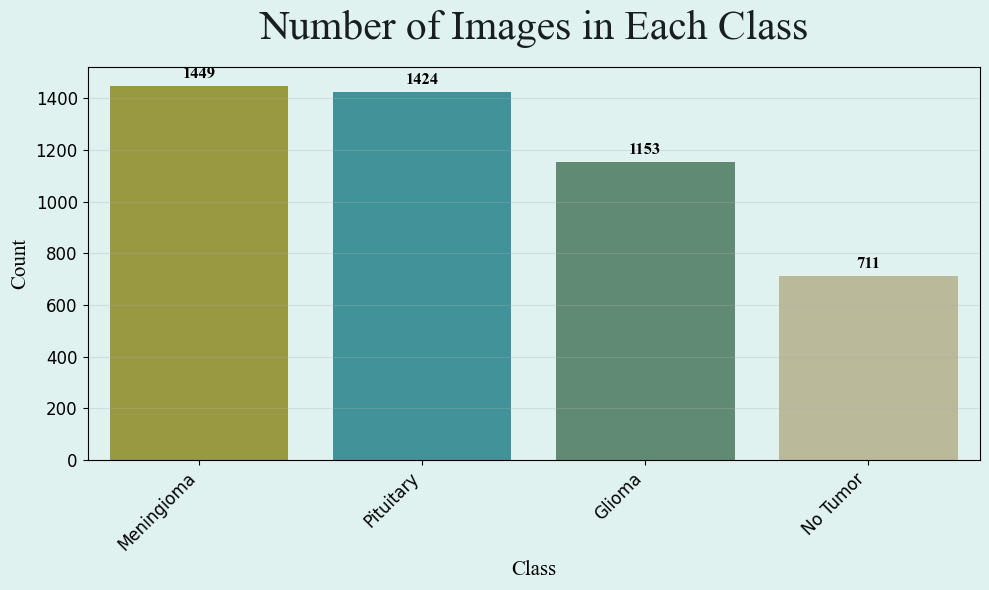

In [24]:
base_path = '../dataset/task3_1-brain-mri/Train'
count_images_in_folders(base_path)

# <p style="background-image: url(https://png.pngtree.com/thumb_back/fh260/background/20231027/pngtree-hexagonal-abstract-background-with-a-black-textured-surface-image_13704307.png);font-family:calibri;font-size:140%;color: #FFD700; text-align:center;border-radius:20px 20px 20px 20px; padding:20px; border:solid 7px #FFD700;"> **LABELS COUNT IN EACH CLASS** 

Number of Labels in Pituitary : 1424
Number of Labels in No Tumor : 711
Number of Labels in Glioma : 1153
Number of Labels in Meningioma : 1449


/var/folders/vb/ln0by8yd5g188n3xwgtwx5dr0000gn/T/ipykernel_39555/3525275016.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df1, x='Class', y='Count', width=0.7, edgecolor='purple', linewidth=2, palette=sns.cubehelix_palette(n_colors=len(df1)))


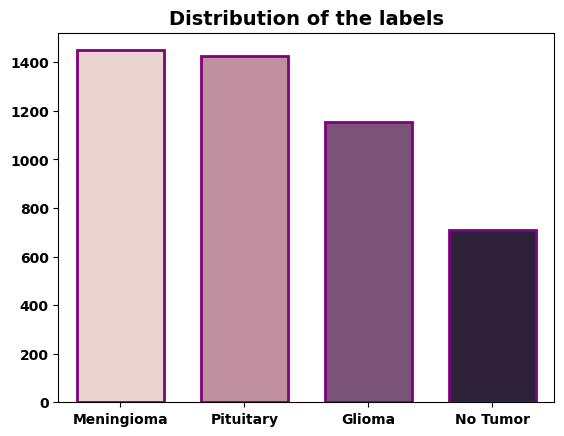

In [26]:
def count_labels_in_folders(base_path):
    label_counts = []
    
    # Get all directories in the base_path
    main_directories = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    
    for main_dir in main_directories:
        label_dir_path = os.path.join(base_path, main_dir, 'labels')
        
        labels = [f for f in os.listdir(label_dir_path) if os.path.isfile(os.path.join(label_dir_path, f))]
        
        print(f'\033[1mNumber of Labels in {main_dir} : {len(labels)}\033[0m')
        label_counts.append({'Class': main_dir, 'Count': len(labels)})
    df1 = pd.DataFrame(label_counts).sort_values(by='Count',ascending=False)

    sns.barplot(df1, x='Class', y='Count', width=0.7, edgecolor='purple', linewidth=2, palette=sns.cubehelix_palette(n_colors=len(df1)))
    plt.title("Distribution of the labels", weight='bold', fontsize=14)
    plt.xticks(color='black',weight='bold')
    plt.yticks(color='black',weight='bold')
    plt.xlabel('', weight='bold', fontsize=14)
    plt.ylabel('',weight='bold', fontsize=14)
    plt.grid(False)
    return 

base_path = '../dataset/task3_1-brain-mri/Train'
count_labels_in_folders(base_path)

# <p style="background-image: url(https://png.pngtree.com/thumb_back/fh260/background/20231027/pngtree-hexagonal-abstract-background-with-a-black-textured-surface-image_13704307.png);font-family:calibri;font-size:140%;color: #FFD700; text-align:center;border-radius:20px 20px 20px 20px; padding:20px; border:solid 7px #FFD700;"> **YAML CONFIGURATION FILE FOR YOLO** 

**YAML (YAML Ain't Markup Language)** is a human-readable data serialization format that is often used for configuration files and data exchange between languages with different data structures. 

In [28]:
# Create YOLOv8 Dataset Configuration File
dataset_yaml = {
    'path': '/kaggle/input/mri-for-brain-tumor-with-bounding-boxes',
    'train': 'Train',
    'val': 'Val',
    'names': ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
}

with open('../dataset/task3_1-brain-mri/dataset_yaml.yaml', 'w') as file:
    yaml.dump(dataset_yaml, file)

# <p style="background-image: url(https://png.pngtree.com/thumb_back/fh260/background/20231027/pngtree-hexagonal-abstract-background-with-a-black-textured-surface-image_13704307.png);font-family:calibri;font-size:140%;color: #FFD700; text-align:center;border-radius:20px 20px 20px 20px; padding:20px; border:solid 7px #FFD700;"> **BUILDING & TRAINING YOLO** 

In [37]:
model = YOLO('yolov8n.yaml')
model = YOLO('yolov8n.pt')
train_results = model.train(data='../dataset/task3_1-brain-mri/dataset_yaml.yaml' , epochs=5, imgsz=640)

Ultralytics 8.4.33 🚀 Python-3.14.0 torch-2.11.0 CPU (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset/task3_1-brain-mri/dataset_yaml.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

KeyboardInterrupt: 

# <p style="background-image: url(https://png.pngtree.com/thumb_back/fh260/background/20231027/pngtree-hexagonal-abstract-background-with-a-black-textured-surface-image_13704307.png);font-family:calibri;font-size:140%;color: #FFD700; text-align:center;border-radius:20px 20px 20px 20px; padding:20px; border:solid 7px #FFD700;"> **DISPLAYING BOUNDING BOXES WITH CLASS & ACCURACY** 

# **Predictions Results**
Yolo_model.predict(image) methode returns a list of three things:\
**1. Bounding Boxes.\
2. Confidence scores.\
3. Class labels.**

Here **model.predict(img)[0]** represents the first prediction in a list for a first image in a batch

In [35]:
classes = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

# Function to display detection results with highlighted parts
def display_samples(images, model):
    fig, axes = plt.subplots(5,2,figsize=(15, 20))
    fig.suptitle('YOLOv8 Detection')
    axes = axes.flatten()
    
    selected_images = random.sample(images, 10)
    
    for i, img in enumerate(selected_images):
        result = model.predict(img)[0]  
        ax=axes[i]
        ax.imshow(img)
#         ax = plt.gca()

        for detection in result.boxes:
            x1, y1, x2, y2 = detection.xyxy[0].cpu().numpy()
            conf = detection.conf[0].cpu().numpy()
            cls = detection.cls[0].cpu().numpy()
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1, f"{classes[int(cls)]} {conf:.2f}", color='white', fontsize=12, backgroundcolor='red')
    plt.tight_layout() 

TypeError: Population must be a sequence.  For dicts or sets, use sorted(d).

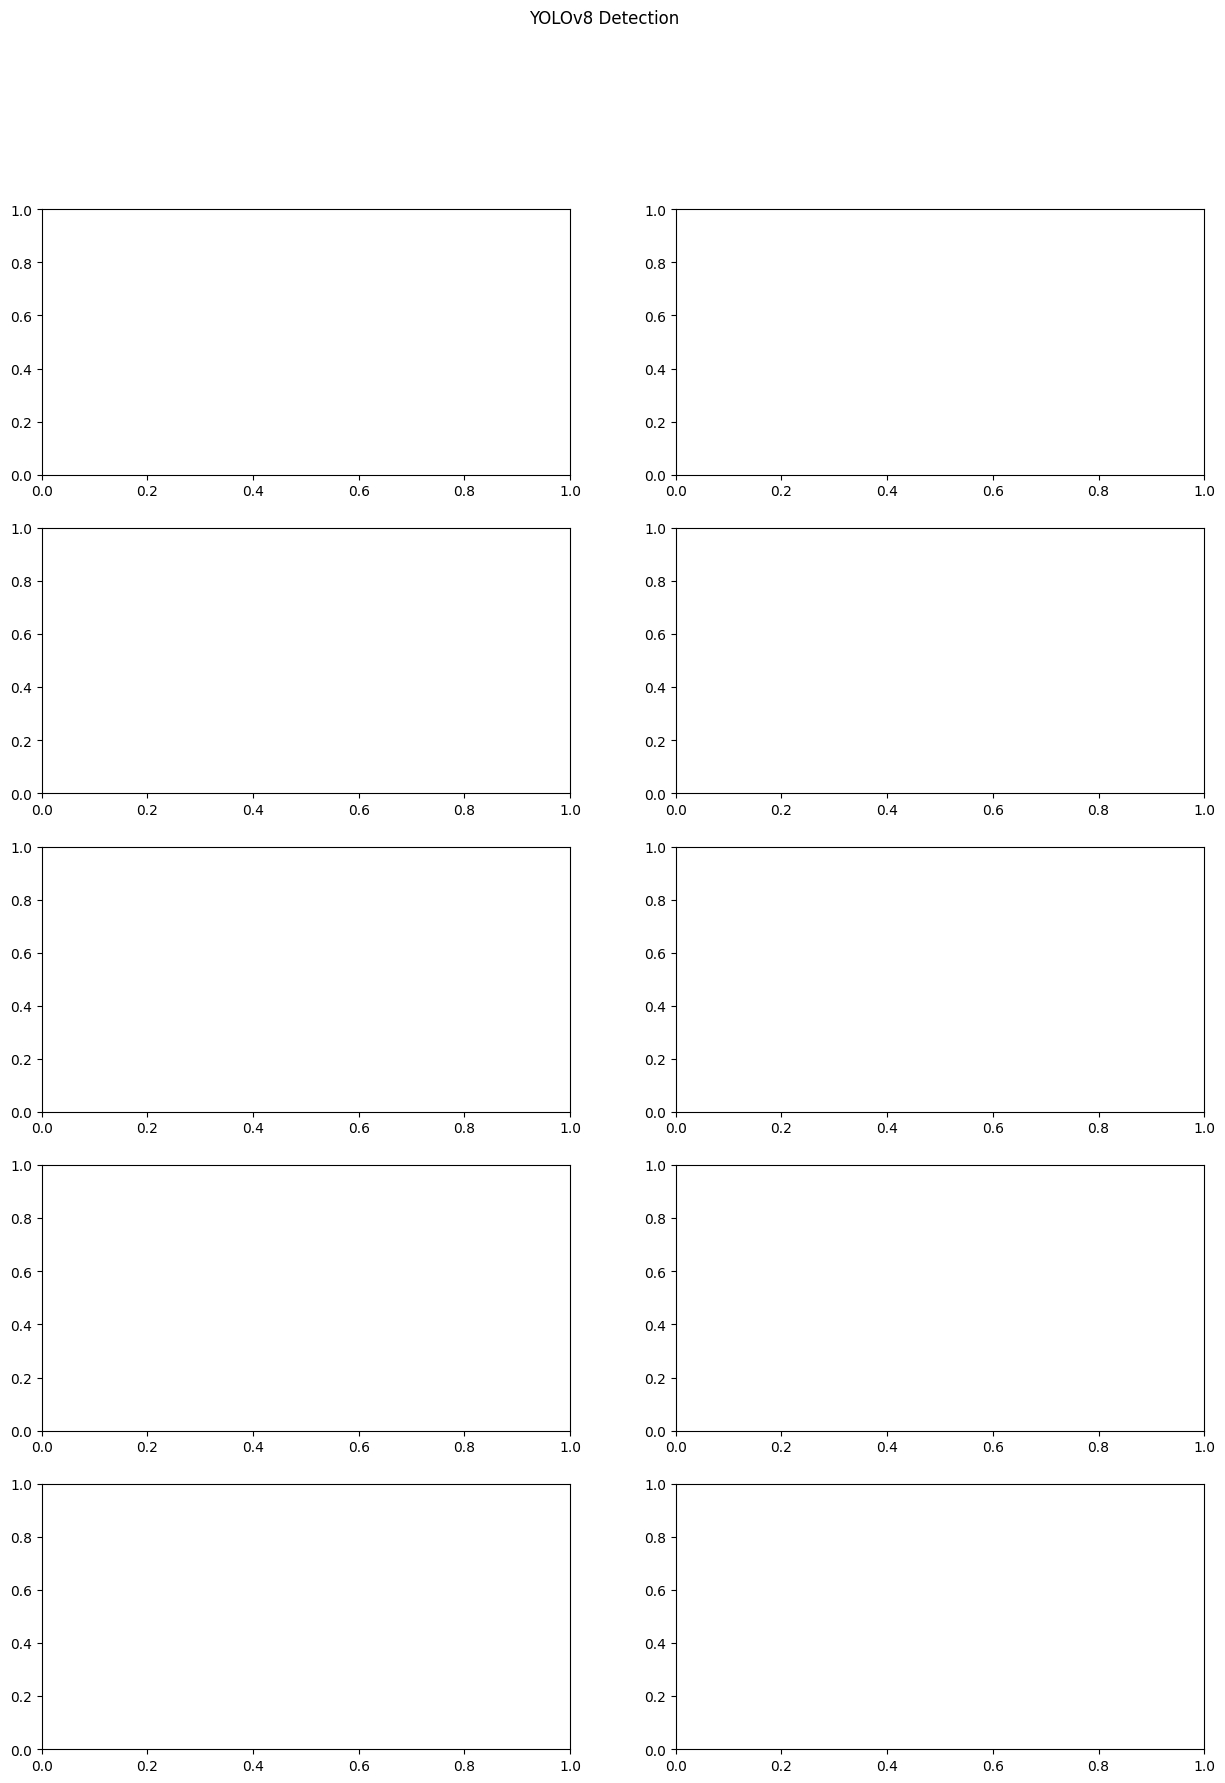

In [36]:
display_samples(val_images, model)

# <p style="background-image: url(https://png.pngtree.com/thumb_back/fh260/background/20231027/pngtree-hexagonal-abstract-background-with-a-black-textured-surface-image_13704307.png);font-family:calibri;font-size:140%;color: #FFD700; text-align:center;border-radius:20px 20px 20px 20px; padding:20px; border:solid 7px #FFD700;"> **YOLOv8n RESULTS** 

In [34]:
# Path to the results directory (adjust the path based on your setup)
results_dir = '../dataset/task3_1-brain-mri/runs/detect/train'

# List all images in the directory
result_images = [img for img in os.listdir(results_dir) if img.endswith('.jpg') or img.endswith('.png')]

# Display the images
for img_name in result_images:
    img_path = os.path.join(results_dir, img_name)
    img = Image.open(img_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()